In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Load dataset
listings = pd.read_csv("combined_listings_residential.csv", low_memory=False)

In [25]:
# Inspect dataset structure
print("Shape (rows, cols):", listings.shape)
print("\nColumns:")
print(listings.columns)
print("\nPreview:")
print(listings.head())
print("\nData types:")
print(listings.dtypes)

Shape (rows, cols): (540183, 84)

Columns:
Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
      

In [26]:
# Unique property types
property_types = listings['PropertyType'].unique()
print("\nProperty Types Found:")
print(property_types)


Property Types Found:
['Residential']


In [27]:
# Filter residential (sanity check)
listings = listings[listings['PropertyType'] == 'Residential']
print("\nShape after filtering:", listings.shape)


Shape after filtering: (540183, 84)


In [28]:
# Count missing values
missing_counts = listings.isnull().sum()

In [29]:
# Percent missing
missing_percent = (missing_counts / len(listings)) * 100

In [30]:
# Combine into one table
missing_df = pd.DataFrame({
    'MissingCount': missing_counts,
    'MissingPercent': missing_percent
})

In [31]:
print("\nMissing Value Summary:")
print(missing_df.sort_values(by='MissingPercent', ascending=False))


Missing Value Summary:
                          MissingCount  MissingPercent
TaxAnnualAmount                 540183           100.0
FireplacesTotal                 540183           100.0
ElementarySchoolDistrict        540183           100.0
TaxYear                         540183           100.0
BusinessType                    540183           100.0
...                                ...             ...
MlsStatus                            0             0.0
ListingKey                           0             0.0
ListingId                            0             0.0
ListPrice.1                          0             0.0
DaysOnMarket.1                       0             0.0

[84 rows x 2 columns]


In [32]:
# Flag columns with >90% missing
high_missing = missing_df[missing_df['MissingPercent'] > 90]
print("\nColumns with >90% missing:")
print(high_missing)


Columns with >90% missing:
                              MissingCount  MissingPercent
FireplacesTotal                     540183      100.000000
AboveGradeFinishedArea              540183      100.000000
TaxAnnualAmount                     540183      100.000000
BuilderName                         514943       95.327509
TaxYear                             540183      100.000000
BuildingAreaTotal                   492186       91.114678
ElementarySchoolDistrict            540183      100.000000
CoBuyerAgentFirstName               525755       97.329053
BelowGradeFinishedArea              537154       99.439264
BusinessType                        540183      100.000000
CoveredSpaces                       540183      100.000000
LotSizeDimensions                   511990       94.780843
MiddleOrJuniorSchoolDistrict        540183      100.000000


In [33]:
# Drop high-missing columns (except core ones)
core_cols = ['ListPrice', 'LivingArea', 'DaysOnMarket']
cols_to_drop = [col for col in high_missing.index if col not in core_cols]
listings = listings.drop(columns=cols_to_drop)
print("\nDropped columns:", cols_to_drop)


Dropped columns: ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']


In [34]:
# Numeric distribution summary
numeric_cols = [ 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt' ]
numeric_cols = [col for col in numeric_cols if col in listings.columns]
summary = listings[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
print("\nNumeric Summary:")
print(summary)


Numeric Summary:
          ListPrice  OriginalListPrice    LivingArea  LotSizeAcres  \
count  5.401830e+05       5.394090e+05  5.396270e+05  4.956650e+05   
mean   1.312997e+06       1.397125e+06  1.980059e+03  6.523781e+01   
std    2.346687e+06       7.357159e+06  2.338269e+04  1.213681e+04   
min    1.000000e+02       0.000000e+00  0.000000e+00  0.000000e+00   
25%    5.800000e+05       5.850000e+05  1.247000e+03  1.200000e-01   
50%    8.400000e+05       8.490000e+05  1.669000e+03  1.700000e-01   
75%    1.375000e+06       1.389000e+06  2.300000e+03  3.140000e-01   
90%    2.345000e+06       2.365040e+06  3.150000e+03  1.340000e+00   
95%    3.450000e+06       3.495000e+06  3.868000e+03  3.573500e+00   
max    1.950000e+08       1.390000e+09  1.702132e+07  4.187292e+06   

       BedroomsTotal  BathroomsTotalInteger   DaysOnMarket      YearBuilt  
count  540035.000000          540128.000000  540183.000000  539244.000000  
mean        3.222963               2.626022      19.539904 

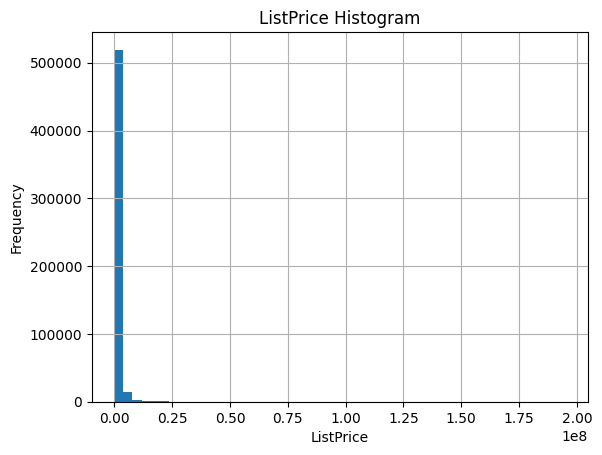

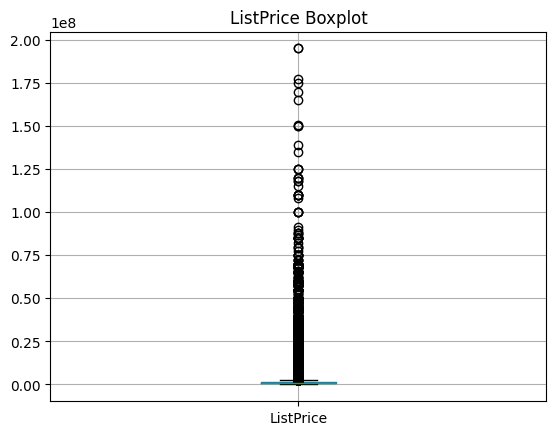

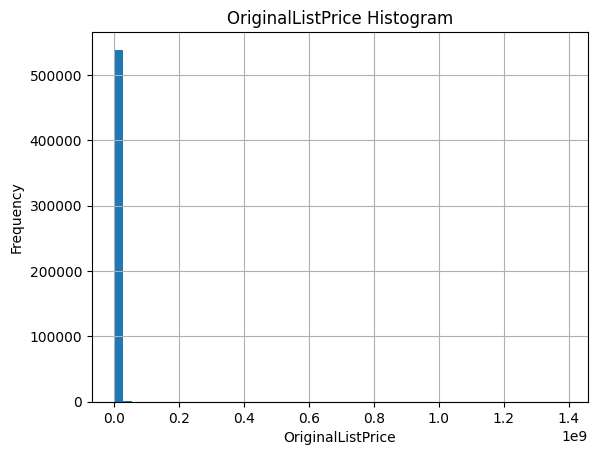

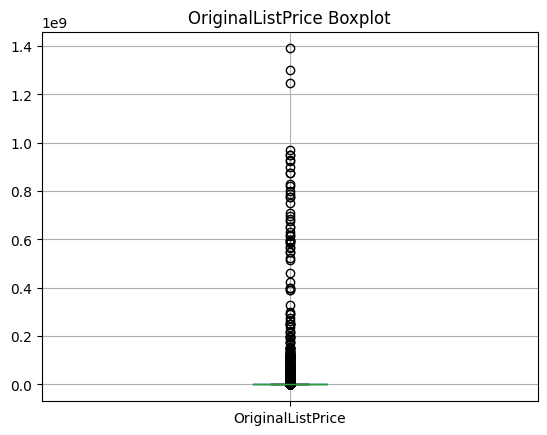

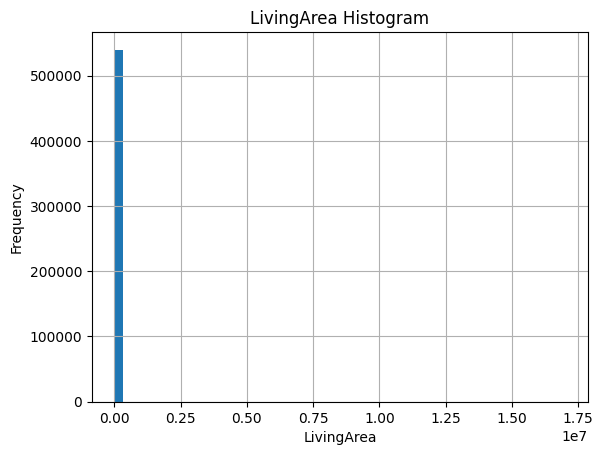

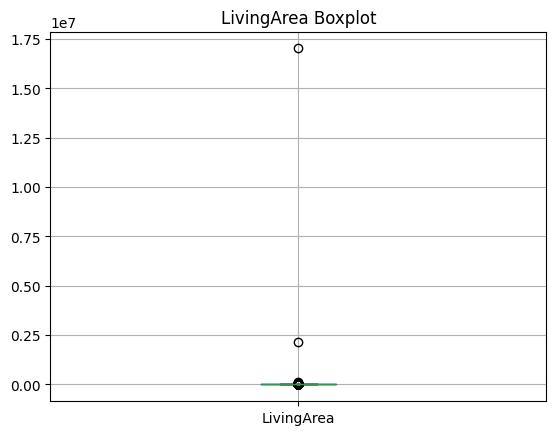

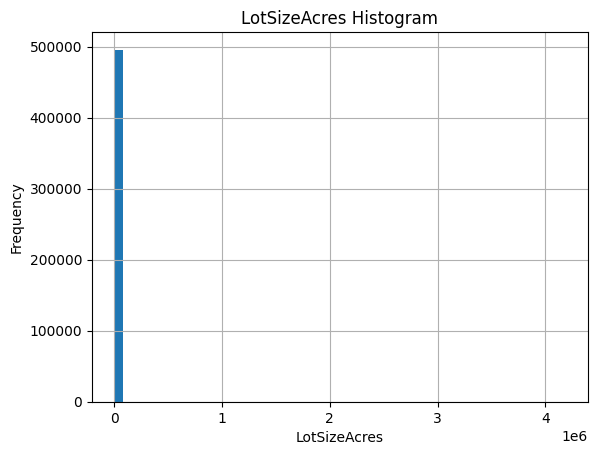

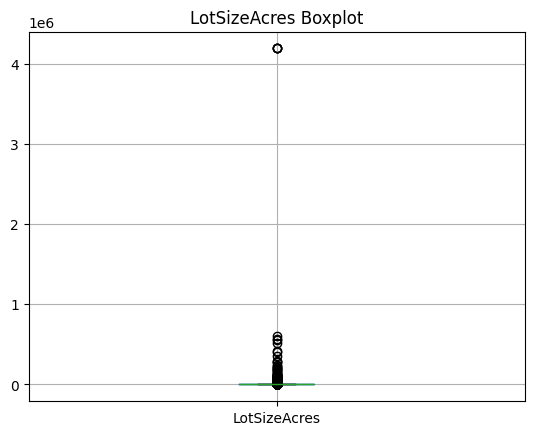

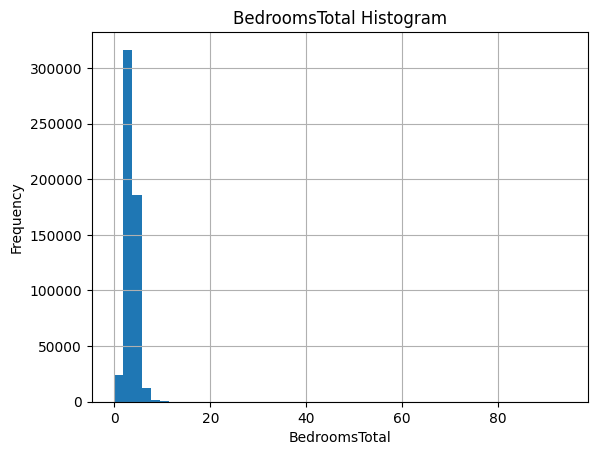

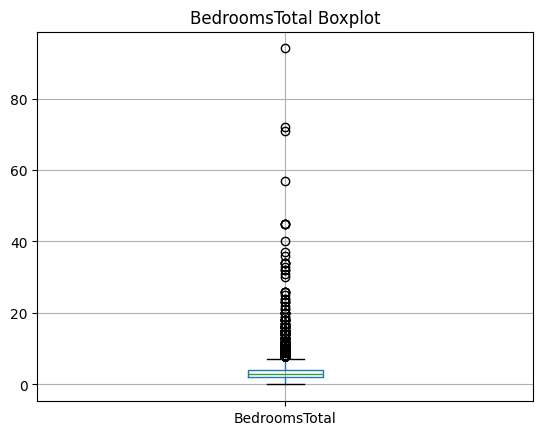

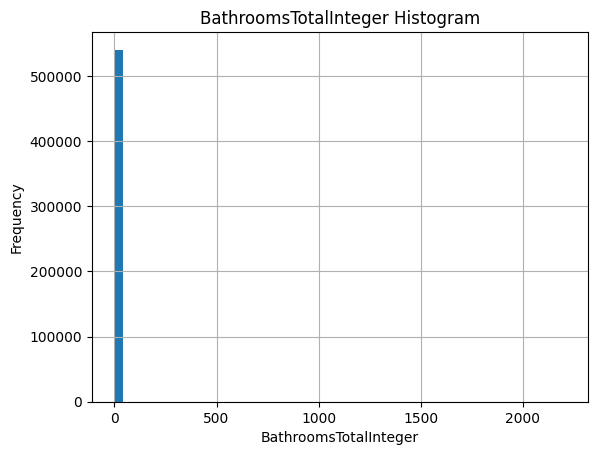

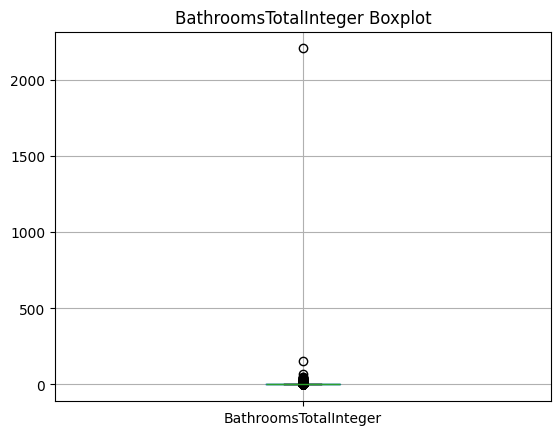

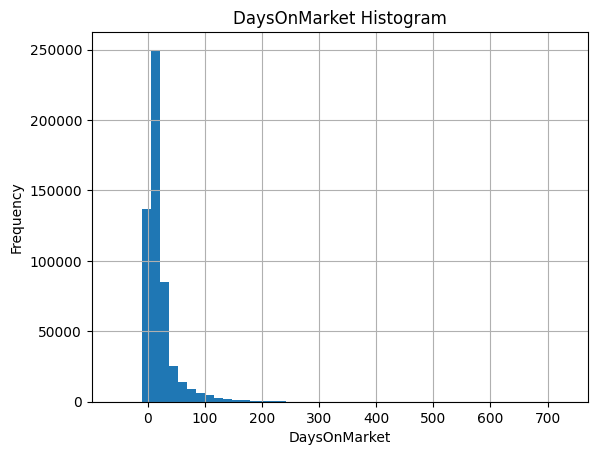

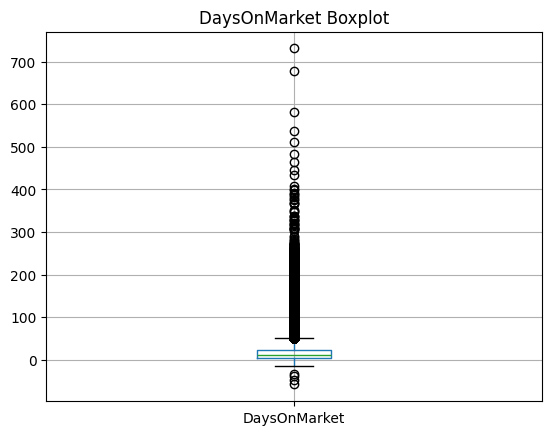

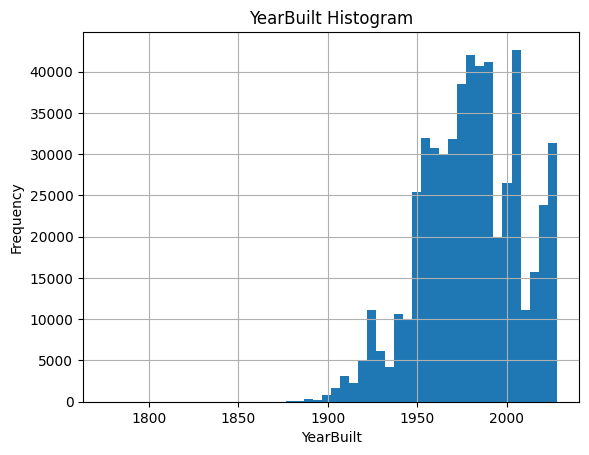

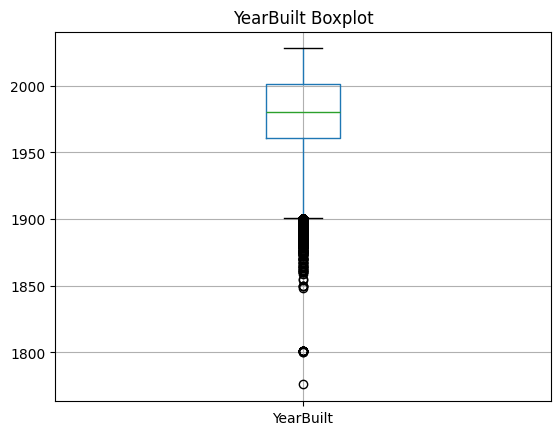

In [35]:
# Histograms and Boxplots
for col in numeric_cols:
    plt.figure()
    listings[col].hist(bins=50)
    plt.title(f"{col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    listings.boxplot(column=col)
    plt.title(f"{col} Boxplot")
    plt.show()

In [36]:
# Negative DaysOnMarket
invalid_dom = listings[listings['DaysOnMarket'] < 0]
print("Negative DaysOnMarket records:", len(invalid_dom))

Negative DaysOnMarket records: 29


In [37]:
# Zero prices
zero_prices = listings[listings['ListPrice'] == 0]
print("Zero price records:", len(zero_prices))

Zero price records: 0


In [38]:
# Flag outliers
print("Max ListPrice:", listings['ListPrice'].max())
print("Max LivingArea:", listings['LivingArea'].max())

Max ListPrice: 195000000.0
Max LivingArea: 17021321.0


In [39]:
# Basic data cleaning
if 'DaysOnMarket' in listings.columns:
    listings = listings[listings['DaysOnMarket'] >= 0]
if 'ListPrice' in listings.columns:
    listings = listings[listings['ListPrice'] > 0]
print("After cleaning shape", listings.shape)

After cleaning shape (540154, 71)


In [40]:
# Residential vs others (already filtered?)
original = pd.read_csv("combined_listings_residential.csv", low_memory=False)
type_counts = original['PropertyType'].value_counts(normalize=True) * 100
print("\nProperty Type Share (%):")
print(type_counts)


Property Type Share (%):
PropertyType
Residential    100.0
Name: proportion, dtype: float64


In [41]:
# Median and Average list price
print("Median List Price:", listings['ListPrice'].median())
print("Average List Price:", listings['ListPrice'].mean())

Median List Price: 840000.0
Average List Price: 1313028.9814619164


In [42]:
# Days on market distribution
print(listings['DaysOnMarket'].describe())

count    540154.000000
mean         19.541523
std          26.770748
min           0.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         731.000000
Name: DaysOnMarket, dtype: float64


In [43]:
# Date consistency check (if available)
if 'ListingContractDate' in listings.columns and 'OnMarketDate' in listings.columns:
    listings['ListingContractDate'] = pd.to_datetime(listings['ListingContractDate'], errors='coerce')
    listings['OnMarketDate'] = pd.to_datetime(listings['OnMarketDate'], errors='coerce')
    invalid_dates = listings[listings['OnMarketDate'] < listings['ListingContractDate']]
    print("Invalid date records:", len(invalid_dates))

In [44]:
# Highest median prices by county
if 'CountyOrParish' in listings.columns:
    county_prices = listings.groupby('CountyOrParish')['ListPrice'].median().sort_values(ascending=False)
    print("\nMedian Price by County:")
    print(county_prices.head(10))


Median Price by County:
CountyOrParish
San Mateo        1648000.0
Santa Clara      1499000.0
Marin            1295000.0
Santa Cruz       1250000.0
Orange           1200000.0
San Francisco    1098000.0
Alameda           998000.0
Monterey          990000.0
Los Angeles       950000.0
San Diego         910000.0
Name: ListPrice, dtype: float64


In [45]:
# Write new CSV file
listings.to_csv("filtered_residential_listings.csv", index = False)